In [2]:
#!pip install seaborn
#!pip install missingno
#!pip install xgboost
#!pip install catboost
#!pip install regex
#!pip install sklearn
#!pip install pandas
#!pip install numpy
#!pip install imblearn
#!pip install lightgbm

In [3]:
import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np   # linear algebra
import matplotlib.pyplot as plt  #graphs and plots
import seaborn as sns   #data visualizations 
import csv # Some extra functionalities for csv  files - reading it as a dictionary
from lightgbm import LGBMClassifier #sklearn is for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction 

from sklearn.model_selection import train_test_split, cross_validate   #break up dataset into train and test sets

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# importing python library for working with missing data
import missingno as msno
# To install missingno use: !pip install missingno
import re    # This library is used to perform regex pattern matching

# import various functions from sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, classification_report, make_scorer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score,\
                            precision_score, recall_score, roc_auc_score,\
                            ConfusionMatrixDisplay, classification_report, RocCurveDisplay, f1_score

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import warnings
warnings.filterwarnings("ignore")

In [4]:
diabetic_raw =pd.read_csv("./output/diabetic_raw.csv")
diabetic_raw.head()


#diabetic.info()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,num_visits,is_repeat_patient,nonAssistance_discharge_disposition_value,high_inpatient_visits,high_medications,chronic_diagnoses,repeat_chronic,visits_medications_ratio,diagnoses_medication_ratio,num_med_time_in_hospital_ratio
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,0,0,0,0,0,0,0,0.0,0.500000,0.500000
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,0,0,1,0,1,1,0,0.0,0.473684,4.500000
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,0,0,1,1,0,0,0,0.0,0.428571,4.333333
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,0,0,1,0,1,0,0,0.0,0.411765,5.333333
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,0,0,1,0,0,0,0,0.0,0.555556,4.000000


In [5]:
list(diabetic_raw)

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'admission_type_text',
 'admission_source_text',
 'discharge_disposition_text',
 'age_value',
 'time_in_hospital_value',
 'age_targe

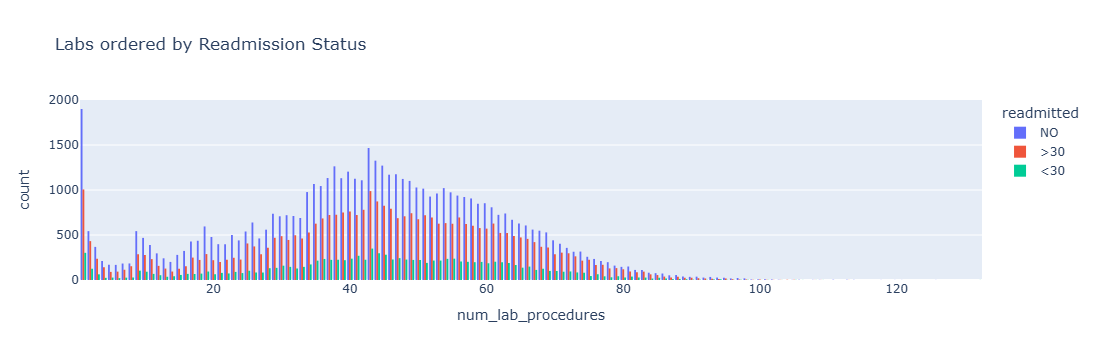

In [6]:
px.histogram(diabetic_raw, x="num_lab_procedures", color="readmitted", barmode="group", title="Labs ordered by Readmission Status")

In [7]:
px.histogram(diabetic_raw, x="num_lab_procedures", color="readmitted_value", title="Labs ordered by Readmission Status")

In [12]:
diabetic_raw["lab_bin"] = pd.cut(
    diabetic_raw["num_lab_procedures"],
    bins=10,
    precision=0
)


In [14]:
# Calculate percentage of each readmitted_value within each bin
df_pct = (
    diabetic_raw
    .groupby(["lab_bin", "readmitted_value"])
    .size()
    .reset_index(name="count")
)

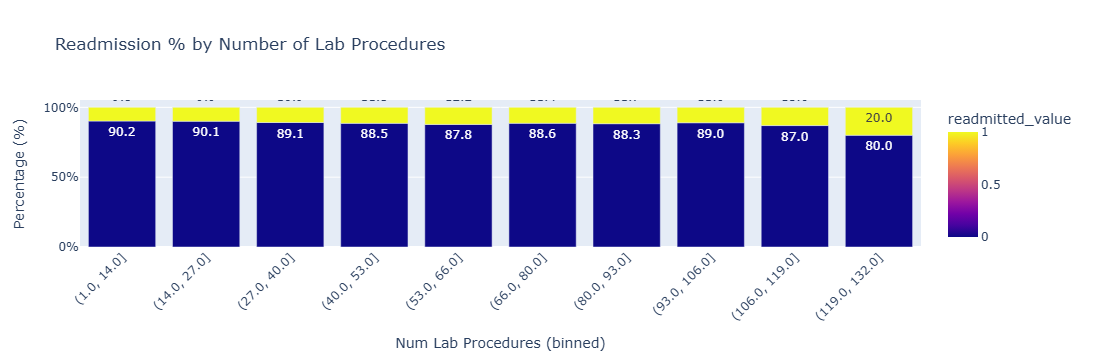

In [15]:
# Readmission rate based on number of lab procedures
df_pct["pct"] = df_pct.groupby("lab_bin")["count"].transform(lambda x: x / x.sum() * 100)
df_pct["lab_bin"] = df_pct["lab_bin"].astype(str)  # convert interval to string for plotly

fig = px.bar(
    df_pct,
    x="lab_bin",
    y="pct",
    color="readmitted_value",
    barmode="stack",
    title="Readmission % by Number of Lab Procedures",
    labels={"lab_bin": "Num Lab Procedures (binned)", "pct": "Percentage (%)"},
    text_auto=".1f"
)
fig.update_layout(yaxis_ticksuffix="%", xaxis_tickangle=-45)
fig.show()

In [19]:
df_med_rate = (
    diabetic_raw
    .groupby("num_medications")["readmitted_value"]
    .mean()
    .reset_index()
)
df_med_rate["readmission_rate_pct"] = df_med_rate["readmitted_value"] * 100

# Calculate linear trendline
slope, intercept, _, _, _ = linregress(df_med_rate["num_medications"], df_med_rate["readmission_rate_pct"])
trendline_y = slope * df_med_rate["num_medications"] + intercept

fig = go.Figure()

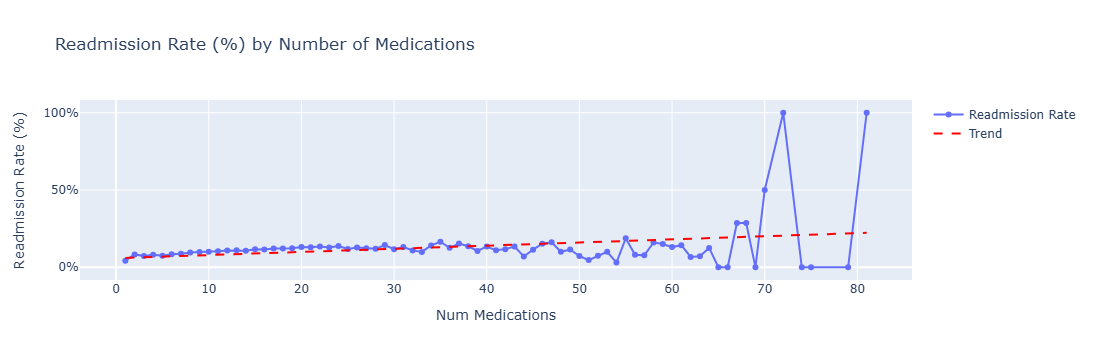

In [20]:
fig.add_trace(go.Scatter(
    x=df_med_rate["num_medications"],
    y=df_med_rate["readmission_rate_pct"],
    mode="lines+markers",
    name="Readmission Rate"
))

# Trendline
fig.add_trace(go.Scatter(
    x=df_med_rate["num_medications"],
    y=trendline_y,
    mode="lines",
    name="Trend",
    line=dict(color="red", dash="dash", width=2)
))

fig.update_layout(
    title="Readmission Rate (%) by Number of Medications",
    xaxis_title="Num Medications",
    yaxis_title="Readmission Rate (%)",
    yaxis_ticksuffix="%"
)
fig.show()

In [21]:
# Bin num_medications into groups
diabetic_raw["med_bin"] = pd.cut(
    diabetic_raw["num_medications"],
    bins=10,
    precision=0
)

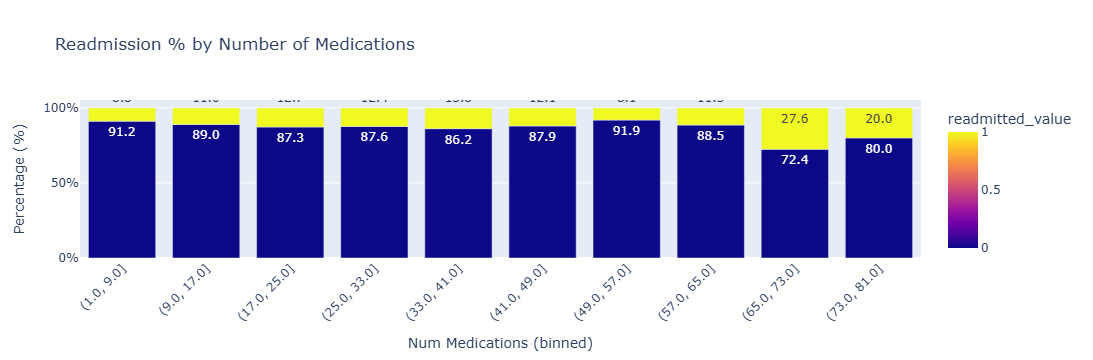

In [22]:
# Calculate percentage of each readmitted_value within each bin
df_pct = (
    diabetic_raw
    .groupby(["med_bin", "readmitted_value"])
    .size()
    .reset_index(name="count")
)
df_pct["pct"] = df_pct.groupby("med_bin")["count"].transform(lambda x: x / x.sum() * 100)
df_pct["med_bin"] = df_pct["med_bin"].astype(str)

fig = px.bar(
    df_pct,
    x="med_bin",
    y="pct",
    color="readmitted_value",
    barmode="stack",
    title="Readmission % by Number of Medications",
    labels={"med_bin": "Num Medications (binned)", "pct": "Percentage (%)"},
    text_auto=".1f"
)
fig.update_layout(yaxis_ticksuffix="%", xaxis_tickangle=-45)
fig.show()